In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

In [2]:
fund_master=pd.read_csv("01_fund_master_cleaned.csv")

nav_history=pd.read_csv("02_nav_history_cleaned.csv")

aum=pd.read_csv("03_aum_by_fund_house_cleaned.csv")

sip=pd.read_csv("04_monthly_sip_inflows_cleaned.csv")

category=pd.read_csv("05_category_inflows_cleaned.csv")

folio=pd.read_csv("06_industry_folio_count_cleaned.csv")

performance=pd.read_csv("07_scheme_performance_cleaned.csv")

transactions=pd.read_csv("08_investor_transactions_cleaned.csv")

holdings=pd.read_csv("09_portfolio_holdings_cleaned.csv")

benchmark=pd.read_csv("10_benchmark_indices_cleaned.csv")

In [3]:
nav_history["date"]=pd.to_datetime(nav_history["date"])

aum["date"]=pd.to_datetime(aum["date"])

sip["month"]=pd.to_datetime(sip["month"])

folio["month"]=pd.to_datetime(folio["month"])

transactions["transaction_date"]=pd.to_datetime(transactions["transaction_date"])

benchmark["date"]=pd.to_datetime(benchmark["date"])

In [4]:
fig=px.line(
    nav_history,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend"
)

fig.show()

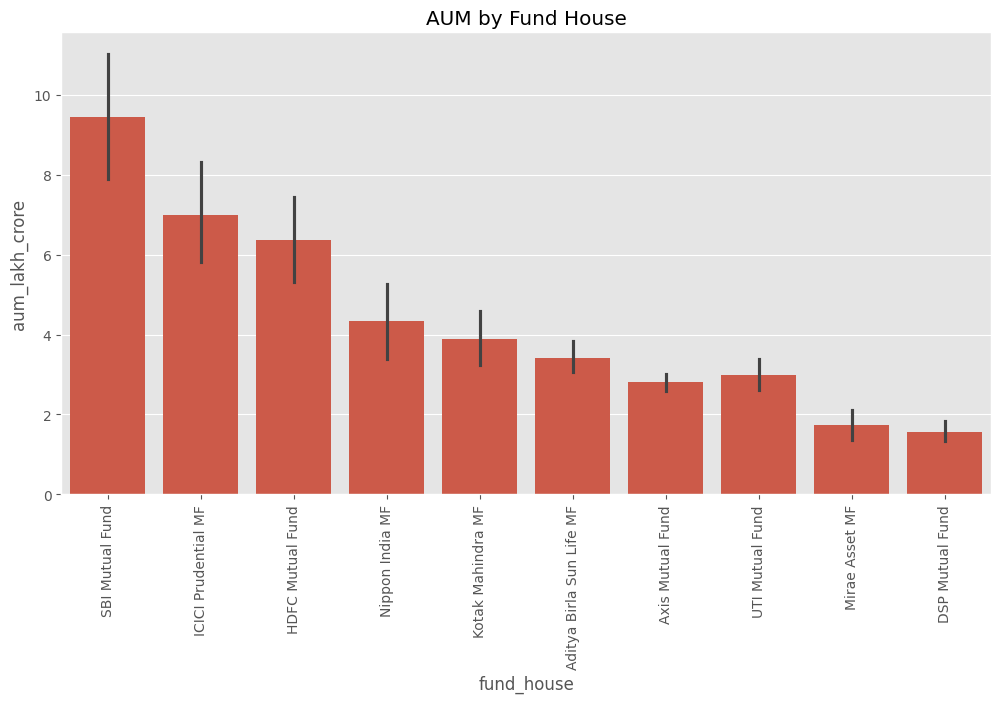

In [5]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_lakh_crore"
)

plt.xticks(rotation=90)

plt.title("AUM by Fund House")

plt.show()

In [6]:
fig=px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow"
)

fig.show()

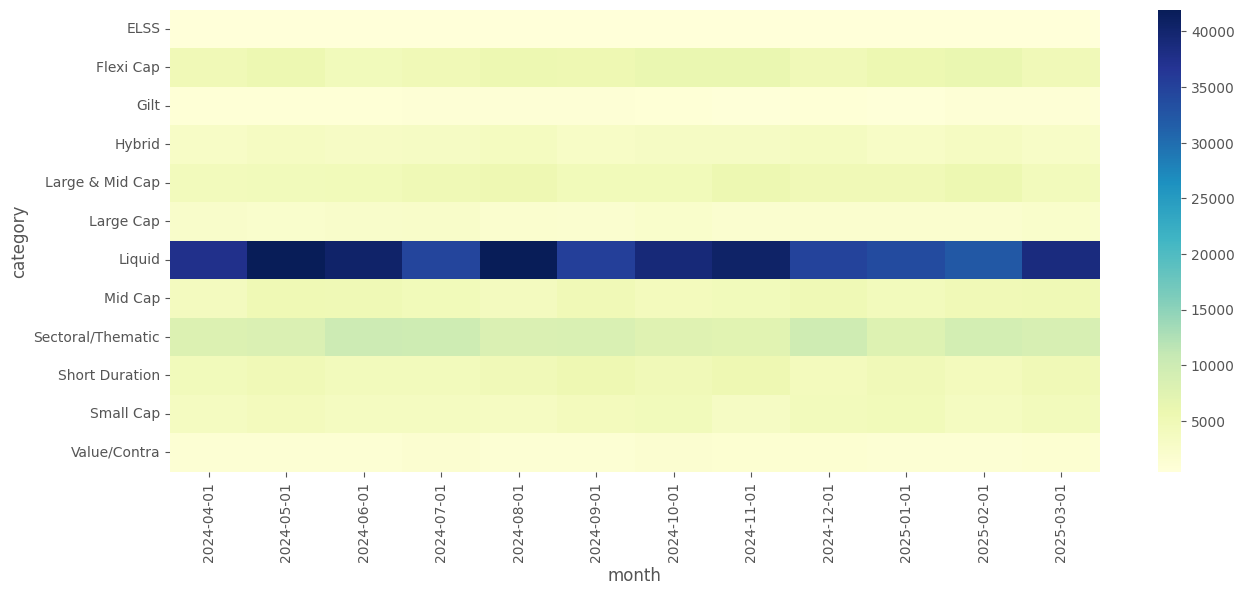

In [7]:
pivot=category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(15,6))

sns.heatmap(pivot,cmap="YlGnBu")

plt.show()

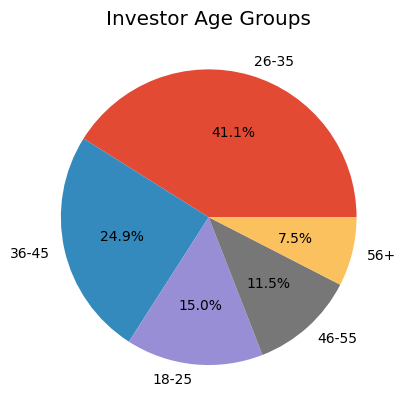

In [8]:
transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Investor Age Groups")

plt.show()

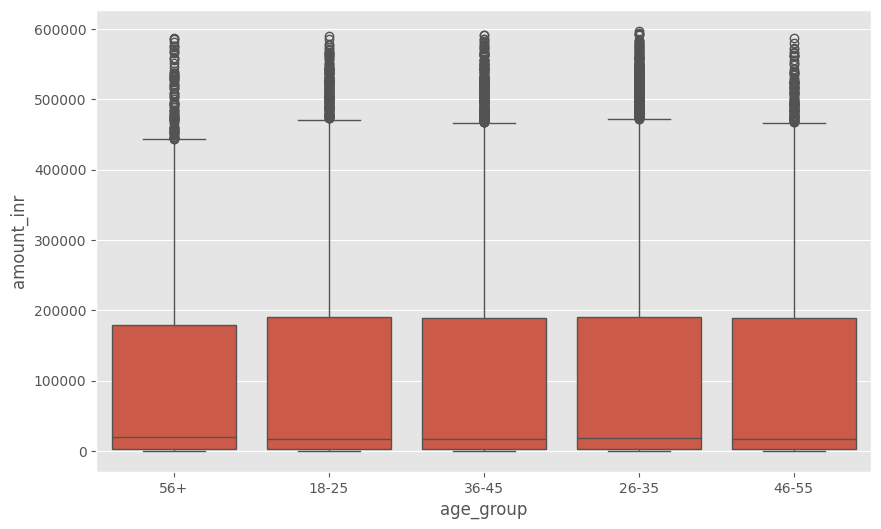

In [9]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.show()

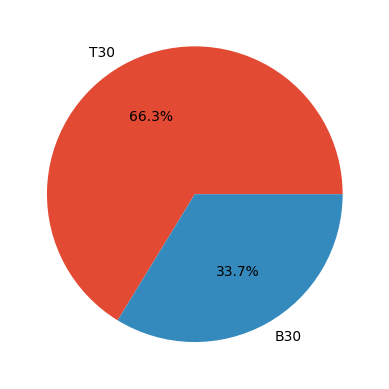

In [10]:
transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.show()

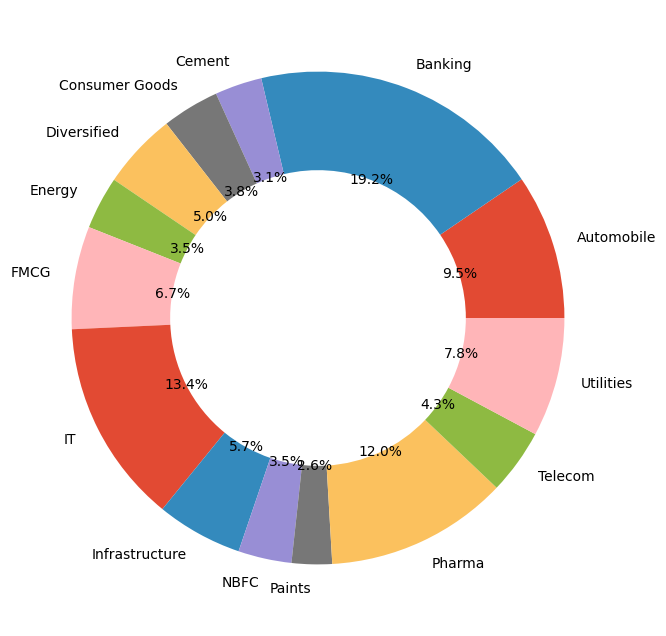

In [11]:
sector=holdings.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    wedgeprops=dict(width=0.4),
    autopct="%1.1f%%"
)

plt.show()

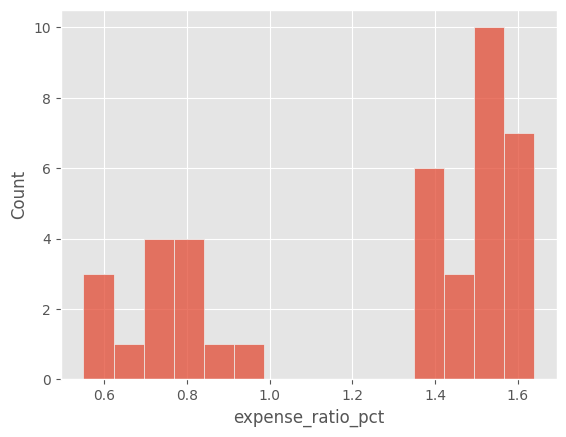

In [12]:
sns.histplot(
    performance["expense_ratio_pct"],
    bins=15
)

plt.show()